In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,recall_score, f1_score
import joblib  
import numpy as np

In [3]:
svc_model=joblib.load('../models/svm_mnist_model.pkl')  #导入训练好的模型
X = np.loadtxt('../data/processed/digits4000_normalized.txt', delimiter='\t')
y=np.loadtxt('../data/raw/digits4000/digits4000_digits_labels.txt', delimiter='\t')
y_test=y[0:2000]
X_test = X[0:2000]
X_test.shape

(2000, 784)

In [4]:
#利用模型进行预测
y_pred = svc_model.predict(X_test)
y_pred

array([0., 0., 0., ..., 9., 9., 9.], shape=(2000,))

In [19]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm


Confusion Matrix:


array([[193,   0,   3,   0,   0,   2,   1,   0,   1,   0],
       [  0, 194,   1,   1,   0,   1,   2,   0,   0,   1],
       [  0,   2, 187,   2,   6,   1,   0,   1,   1,   0],
       [  0,   0,   3, 186,   0,   4,   0,   1,   4,   2],
       [  0,   1,   5,   0, 186,   0,   2,   0,   2,   4],
       [  0,   0,   1,   4,   1, 188,   4,   0,   1,   1],
       [  0,   0,   7,   0,   0,   0, 193,   0,   0,   0],
       [  0,   2,   2,   1,   1,   2,   0, 188,   2,   2],
       [  0,   1,   1,   4,   2,   2,   0,   0, 189,   1],
       [  1,   1,   1,   1,   3,   2,   0,   4,   2, 185]])

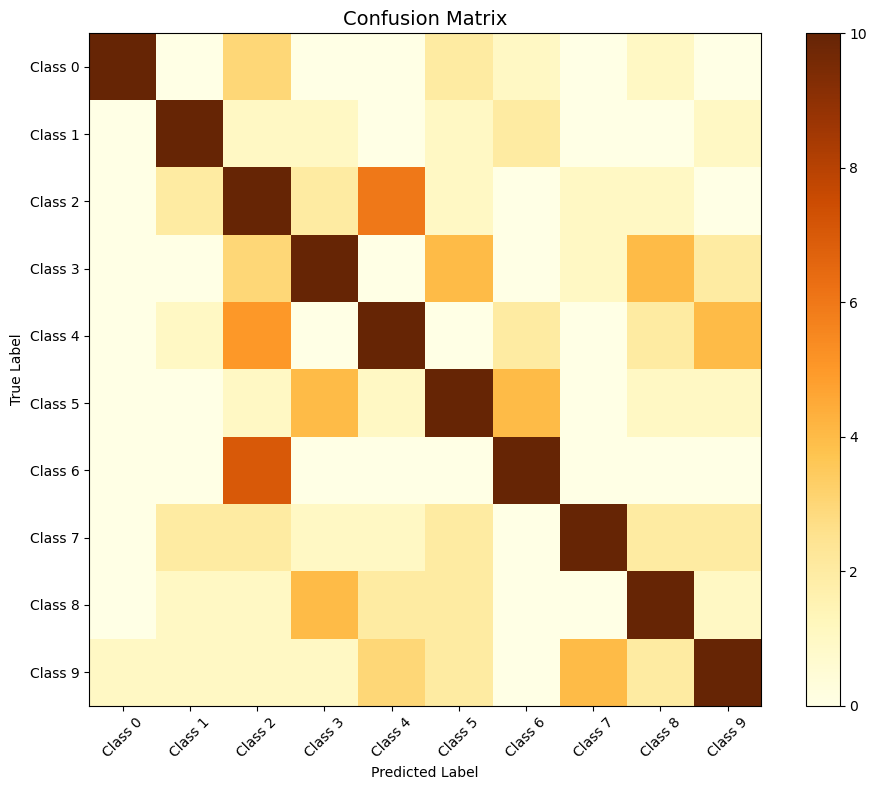

In [20]:
from matplotlib.colors import Normalize
#可视化混淆矩阵
class MidpointNormalize(Normalize):
    def __init__(self, vmin=None, vmax=None, clip=False):
        super().__init__(vmin, vmax, clip)

plt.figure(figsize=(10, 8))
im = plt.imshow(cm, interpolation='nearest', cmap='YlOrBr', vmin=0, vmax=10)
plt.title('Confusion Matrix', fontsize=14)
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, [f'Class {i}' for i in range(10)], rotation=45)
plt.yticks(tick_marks, [f'Class {i}' for i in range(10)])

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [22]:
n_classes = len(np.unique(y_test))
n_classes

10

In [27]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"\n准确率: {accuracy:.4f}")
print(f"召回率: {recall:.4f}")
print(f"F1分数: {f1:.4f}")


准确率: 0.9445
召回率: 0.9445
F1分数: 0.9446


In [28]:
report = classification_report(y_test, y_pred)
print(report)


              precision    recall  f1-score   support

         0.0       0.99      0.96      0.98       200
         1.0       0.97      0.97      0.97       200
         2.0       0.89      0.94      0.91       200
         3.0       0.93      0.93      0.93       200
         4.0       0.93      0.93      0.93       200
         5.0       0.93      0.94      0.94       200
         6.0       0.96      0.96      0.96       200
         7.0       0.97      0.94      0.95       200
         8.0       0.94      0.94      0.94       200
         9.0       0.94      0.93      0.93       200

    accuracy                           0.94      2000
   macro avg       0.95      0.94      0.94      2000
weighted avg       0.95      0.94      0.94      2000



# Model Performance Summary:
- Macro-average F1 score: 0.94
- Best digits: 0, 1, 6 (F1 > 0.96)
- Problematic digit: 2 (F1 = 0.91)
 - Key issue: Low precision (0.89) for digit 2
 - Main confusion pairs: 2↔3, 2↔8, 7↔1, 3↔5

Recommendations:
- Increase training samples for digit 2
- Feature optimization for confusion pairs involving digit 2
  
模型在数字识别任务上整体表现良好，宏平均F1分数达到0.94。其中，数字0、1、6的识别效果最佳（F1 > 0.96），而数字2的识别效果相对较差（F1=0.91），主要表现为精确率偏低（0.89），表明部分其他数字被误判为2。建议后续通过增加数字2的训练样本或针对2与其他数字的混淆对进行特征优化来改进模型性能。